In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.datasets import fetch_california_housing

# Load dataset
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['PRICE'] = california.target

# Display first few rows
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# Basic statistics
print("\nDataset Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000

### Data visualization


Correlation with Price:
PRICE         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: PRICE, dtype: float64


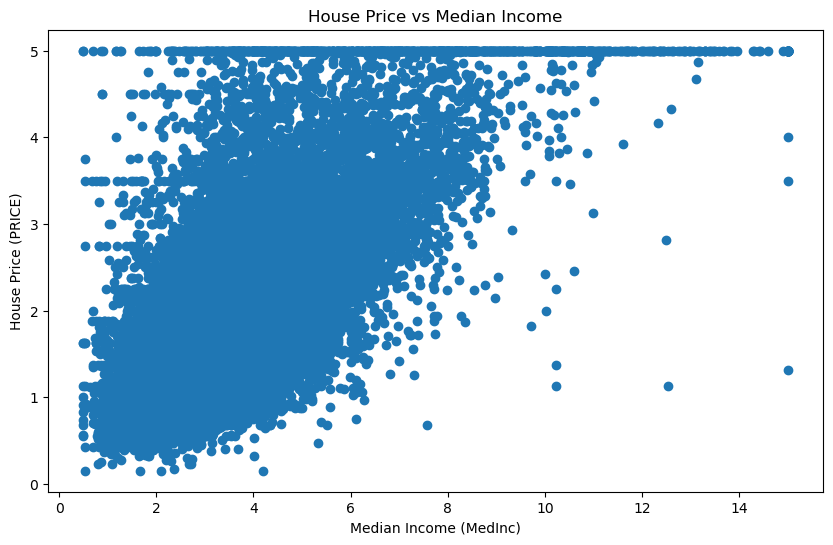

In [5]:
# Correlation matrix
corr_matrix = df.corr()
print("\nCorrelation with Price:")
print(corr_matrix['PRICE'].sort_values(ascending=False))

# Scatter plot of most correlated feature (MedInc - median income)
plt.figure(figsize=(10, 6))
plt.scatter(df['MedInc'], df['PRICE'])
plt.xlabel('Median Income (MedInc)')
plt.ylabel('House Price (PRICE)')
plt.title('House Price vs Median Income')
plt.show()

### Data Preprocessing

In [6]:
# Select features and target
X = df.drop('PRICE', axis=1)  # Target is 'PRICE' in California dataset
y = df['PRICE']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Building Linear Regression from scratch

In [13]:
class LinearRegressionFromScratch:
    def __init__(self, learning_rate=0.001, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []
    
    def fit(self, X, y):
        # Initialize parameters
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Gradient Descent
        for _ in range(self.n_iterations):
            # Predictions
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # Calculate gradients
            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted - y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Calculate and store cost (MSE)
            cost = np.mean((y_predicted - y) ** 2)
            self.cost_history.append(cost)
    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

### Model Training

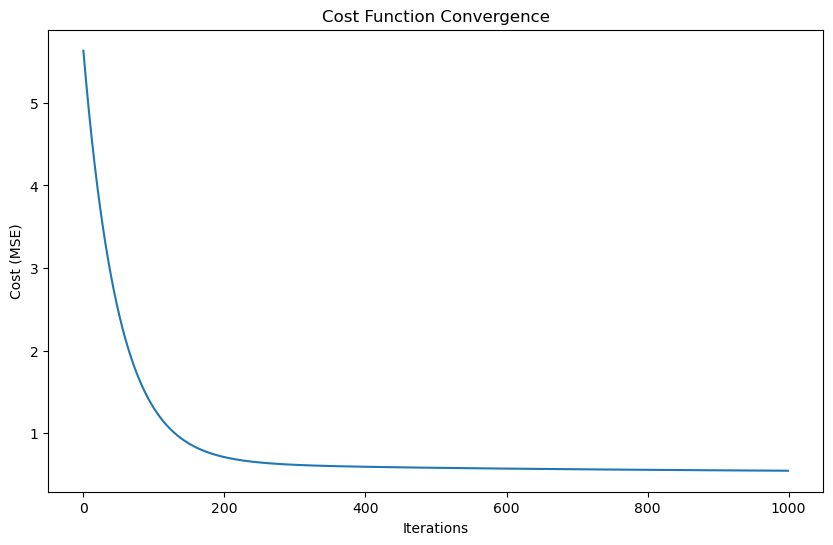

In [14]:
# Initialize and train the model
model = LinearRegressionFromScratch(learning_rate=0.01, n_iterations=1000)
model.fit(X_train_scaled, y_train)

# Plot cost history to check convergence
plt.figure(figsize=(10, 6))
plt.plot(range(model.n_iterations), model.cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Cost Function Convergence')
plt.show()

### Predictions and Evaluation

Mean Squared Error: 0.57
R-squared Score: 0.57


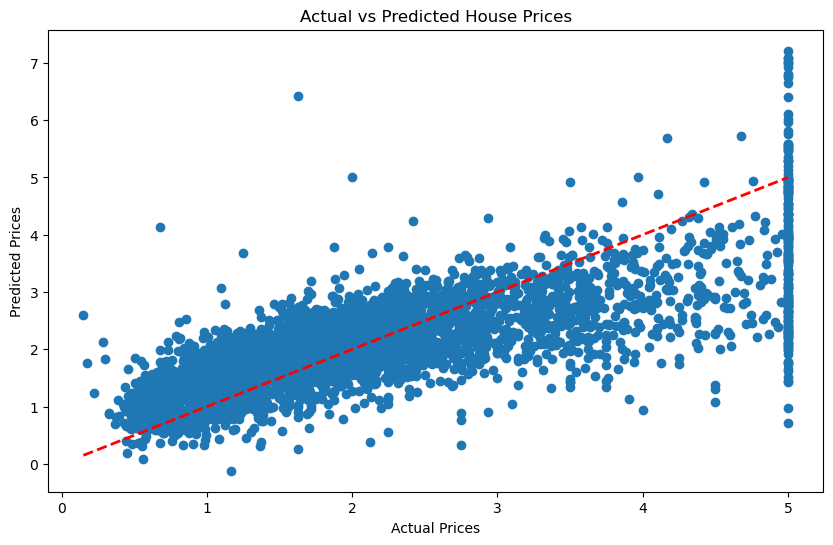

In [15]:
# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r_squared(y_true, y_pred):
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_residual = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_residual / ss_total)

mse = mean_squared_error(y_test, y_pred)
r2 = r_squared(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

# Visualize predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()

 ### Improving


Trying different learning rates...
Learning Rate: 0.001, R-squared: 0.0060
Learning Rate: 0.005, R-squared: 0.5451
Learning Rate: 0.01, R-squared: 0.5672
Learning Rate: 0.05, R-squared: 0.5756

Trying polynomial features...
Polynomial (degree=2) R-squared: 0.5450

Feature Importance:
      Feature  Importance
0      MedInc    0.862511
6    Latitude    0.860795
7   Longitude    0.834459
3   AveBedrms    0.345813
2    AveRooms    0.304980
1    HouseAge    0.126442
5    AveOccup    0.041395
4  Population    0.001027


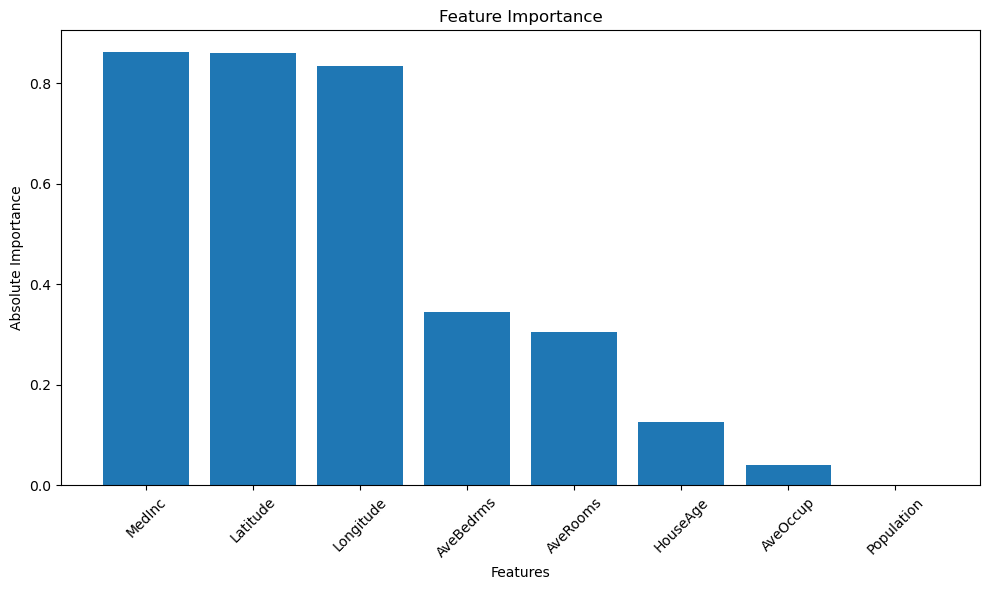

In [12]:
# Let's try to improve the model by:
# 1. Adjusting learning rate
# 2. Increasing number of iterations
# 3. Trying different feature combinations

# Option 1: Try different learning rate
print("\nTrying different learning rates...")
learning_rates = [0.001, 0.005, 0.01, 0.05]
for lr in learning_rates:
    model = LinearRegressionFromScratch(learning_rate=lr, n_iterations=1000)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r_squared(y_test, y_pred)
    print(f"Learning Rate: {lr}, R-squared: {r2:.4f}")

# Option 2: Try polynomial features (simple version)
print("\nTrying polynomial features...")
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

model_poly = LinearRegressionFromScratch(learning_rate=0.01, n_iterations=1000)
model_poly.fit(X_train_poly_scaled, y_train)
y_pred_poly = model_poly.predict(X_test_poly_scaled)
r2_poly = r_squared(y_test, y_pred_poly)
print(f"Polynomial (degree=2) R-squared: {r2_poly:.4f}")

# Option 3: Feature importance analysis
print("\nFeature Importance:")
feature_importance = pd.DataFrame({
    'Feature': california.feature_names,
    'Importance': np.abs(model.weights)
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xticks(rotation=45)
plt.xlabel('Features')
plt.ylabel('Absolute Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

### Let`s compare it with a linear regression from sklearn

Scikit-learn Linear Regression Results:
Mean Squared Error: 0.56
R-squared Score: 0.58

Comparison with From-Scratch Model:
From-Scratch MSE: 0.57, Scikit-learn MSE: 0.56
From-Scratch R2: 0.57, Scikit-learn R2: 0.58


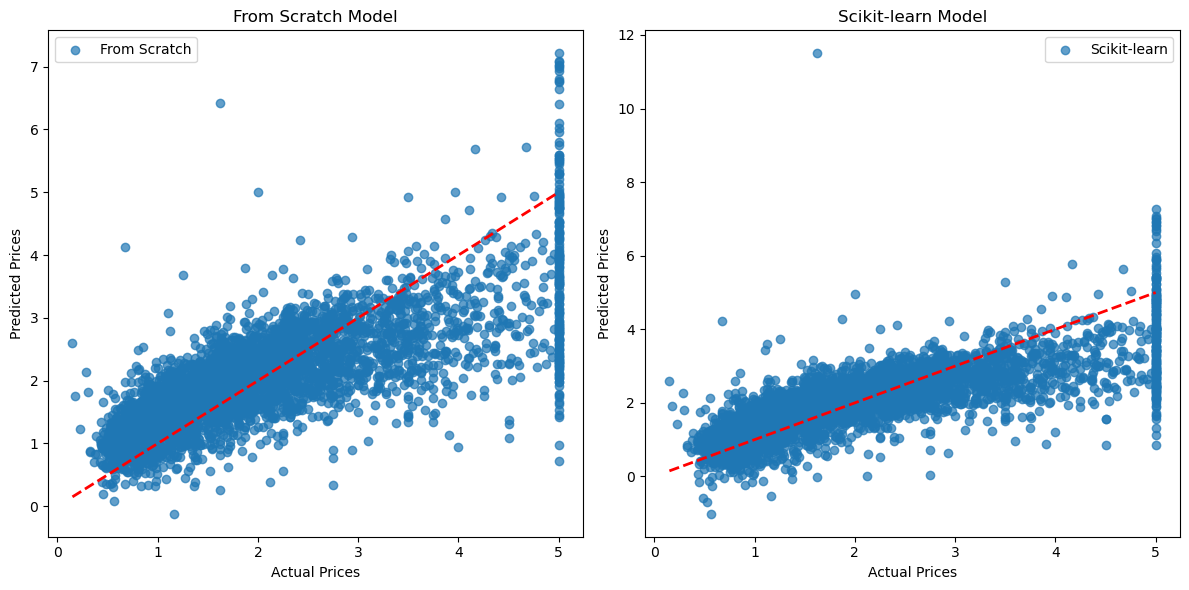


Coefficient Comparison:
      Feature  From Scratch  Scikit-learn
0      MedInc      0.828944      0.854383
1    HouseAge      0.178531      0.122546
2    AveRooms     -0.137949     -0.294410
3   AveBedrms      0.156692      0.339259
4  Population      0.016815     -0.002308
5    AveOccup     -0.045229     -0.040829
6    Latitude     -0.487056     -0.896929
7   Longitude     -0.451471     -0.869842


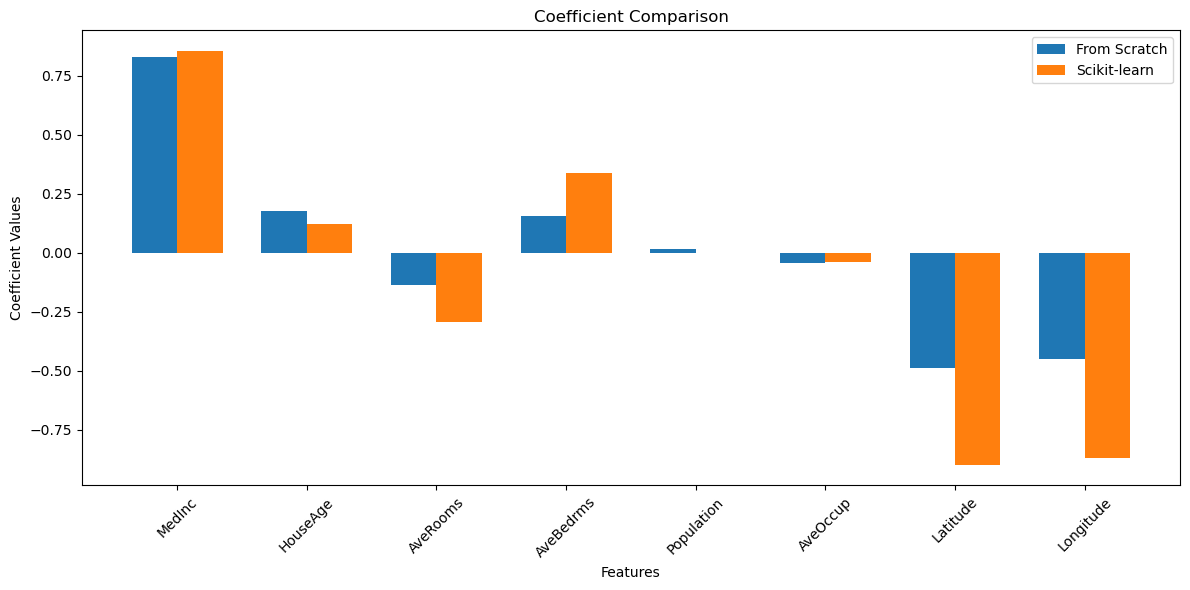

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the scikit-learn model
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_sklearn = sklearn_model.predict(X_test_scaled)

# Evaluate the model
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)
r2_sklearn = r2_score(y_test, y_pred_sklearn)

print("Scikit-learn Linear Regression Results:")
print(f"Mean Squared Error: {mse_sklearn:.2f}")
print(f"R-squared Score: {r2_sklearn:.2f}")

# Compare with our from-scratch model
print("\nComparison with From-Scratch Model:")
print(f"From-Scratch MSE: {mse:.2f}, Scikit-learn MSE: {mse_sklearn:.2f}")
print(f"From-Scratch R2: {r2:.2f}, Scikit-learn R2: {r2_sklearn:.2f}")

# Visualize both predictions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.7, label='From Scratch')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('From Scratch Model')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_sklearn, alpha=0.7, label='Scikit-learn')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Scikit-learn Model')
plt.legend()

plt.tight_layout()
plt.show()

# Compare coefficients
print("\nCoefficient Comparison:")
coefficients_comparison = pd.DataFrame({
    'Feature': california.feature_names,
    'From Scratch': model.weights,
    'Scikit-learn': sklearn_model.coef_
})
print(coefficients_comparison)

# Visualize coefficient comparison
plt.figure(figsize=(12, 6))
x = np.arange(len(california.feature_names))
width = 0.35

plt.bar(x - width/2, model.weights, width, label='From Scratch')
plt.bar(x + width/2, sklearn_model.coef_, width, label='Scikit-learn')
plt.xlabel('Features')
plt.ylabel('Coefficient Values')
plt.title('Coefficient Comparison')
plt.xticks(x, california.feature_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

The scikit-learn implementation slighly better optimized, but our from-scratch model gives pretty similar results